# 한국청소년정책연구원_아동·청소년·청년 데이터 통합조회 (#15154907)
**데이터셋**: data.go.kr #15154907 (국가중점데이터, 사회복지 분야)
**제공기관**: 한국청소년정책연구원 (NYPI)
**API 엔드포인트**: https://data.nypi.re.kr/api/aoePlcyRscrWholInfo
>출처: https://data.nypi.re.kr/aoePlcyRscrWholInfo

---
## 이 데이터셋이 제공하는 것

아동·청소년·청년 데이터 통합조회(#15154907)는 NYPI 4개 주요 조사의 **설문 항목 메타데이터**를
통합 검색하는 API입니다.

| opnDataCd | 조사명 | 설문 항목 수 |
|---|---|---|
| SRVY010101 | 한국아동·청소년패널조사 | 24,135건 |
| SRVY010102 | 다문화청소년패널조사 | 7,555건 |
| SRVY010103 | 한국청소년패널조사 | 6,211건 |
| SRVY010104 | 학업중단패널조사 | 2,970건 |

> 실제 응답 수치(비율·평균)는 각 조사 개별 API에서 제공합니다.
> SchoolBridge 실측값은 #15154775 다문화청소년패널 API(NB01, NB02)에서 가져옵니다.

In [3]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import urllib3
import warnings
warnings.filterwarnings('ignore')
urllib3.disable_warnings()

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
print('패키지 로드 완료')

패키지 로드 완료


## 1. 실제 API 호출 — 4개 조사 카탈로그

In [4]:
# ============================================================
# 통합조회 API 실제 호출
# URL: https://data.nypi.re.kr/api/aoePlcyRscrWholInfo
# ============================================================
SERVICE_KEY = os.environ.get('NYPI_SERVICE_KEY')
BASE = 'https://data.nypi.re.kr/api/aoePlcyRscrWholInfo'

def fetch_integrated(params):
    r = requests.get(BASE, params={**params, 'serviceKey': SERVICE_KEY, '_type': 'json'},
                     timeout=15, verify=False)
    return r.json()

print('=== 통합조회 API 실제 호출 ===')
print(f'엔드포인트: {BASE}')
print()

# 4개 조사 코드 실측
SURVEY_CODES = {
    'SRVY010101': '한국아동·청소년패널조사',
    'SRVY010102': '다문화청소년패널조사',
    'SRVY010103': '한국청소년패널조사',
    'SRVY010104': '학업중단패널조사',
}

catalog_df = []
for cd, nm in SURVEY_CODES.items():
    try:
        d = fetch_integrated({'opnDataCd': cd, 'pageNo': 1, 'numOfRows': 1})
        total = d.get('totalCount', 0)
        sb_rel = cd == 'SRVY010102'  # 다문화패널이 SchoolBridge 직접 연관
        catalog_df.append({'코드': cd, '조사명': nm, '항목수': total, 'SB관련': sb_rel})
        print(f'  {cd} ({nm}): {total:,}건 {"[SchoolBridge 직접 연관]" if sb_rel else ""}')
    except Exception as e:
        print(f'  {cd}: 오류 {e}')

catalog = pd.DataFrame(catalog_df)

# 다문화패널 카테고리 구조 실측
print()
print('=== 다문화청소년패널 카테고리 구조 (실제 API) ===')
d2 = fetch_integrated({'opnDataCd': 'SRVY010102', 'pageNo': 1, 'numOfRows': 300})
cat_counts = {}
for item in d2.get('items', []):
    cat = item.get('otptCtgryNm', '')
    top = cat.split('-')[0].strip()
    cat_counts[top] = cat_counts.get(top, 0) + 1
for cat, cnt in sorted(cat_counts.items(), key=lambda x: -x[1]):
    print(f'  {cat}: {cnt}건')

maps_categories = pd.DataFrame([
    {'카테고리': k, '항목수': v} for k, v in cat_counts.items()
])

print()
print(f'총 조회 항목: {d2.get("totalCount", "?")}건 (페이지당 300건 조회)')

=== 통합조회 API 실제 호출 ===
엔드포인트: https://data.nypi.re.kr/api/aoePlcyRscrWholInfo

  SRVY010101 (한국아동·청소년패널조사): 24,135건 
  SRVY010102 (다문화청소년패널조사): 7,555건 [SchoolBridge 직접 연관]
  SRVY010103 (한국청소년패널조사): 6,211건 
  SRVY010104 (학업중단패널조사): 2,970건 

=== 다문화청소년패널 카테고리 구조 (실제 API) ===
  환경 요인: 70건
  개인 및 환경 요인: 67건
  다문화 관련 요인: 57건
  개인 요인: 43건
  다문화적 특성: 29건
  배경변인: 16건
  배경 변인: 13건
  패널관리: 5건

총 조회 항목: 7555건 (페이지당 300건 조회)


## 2. 시각화 1 — 4개 조사 항목 수 비교

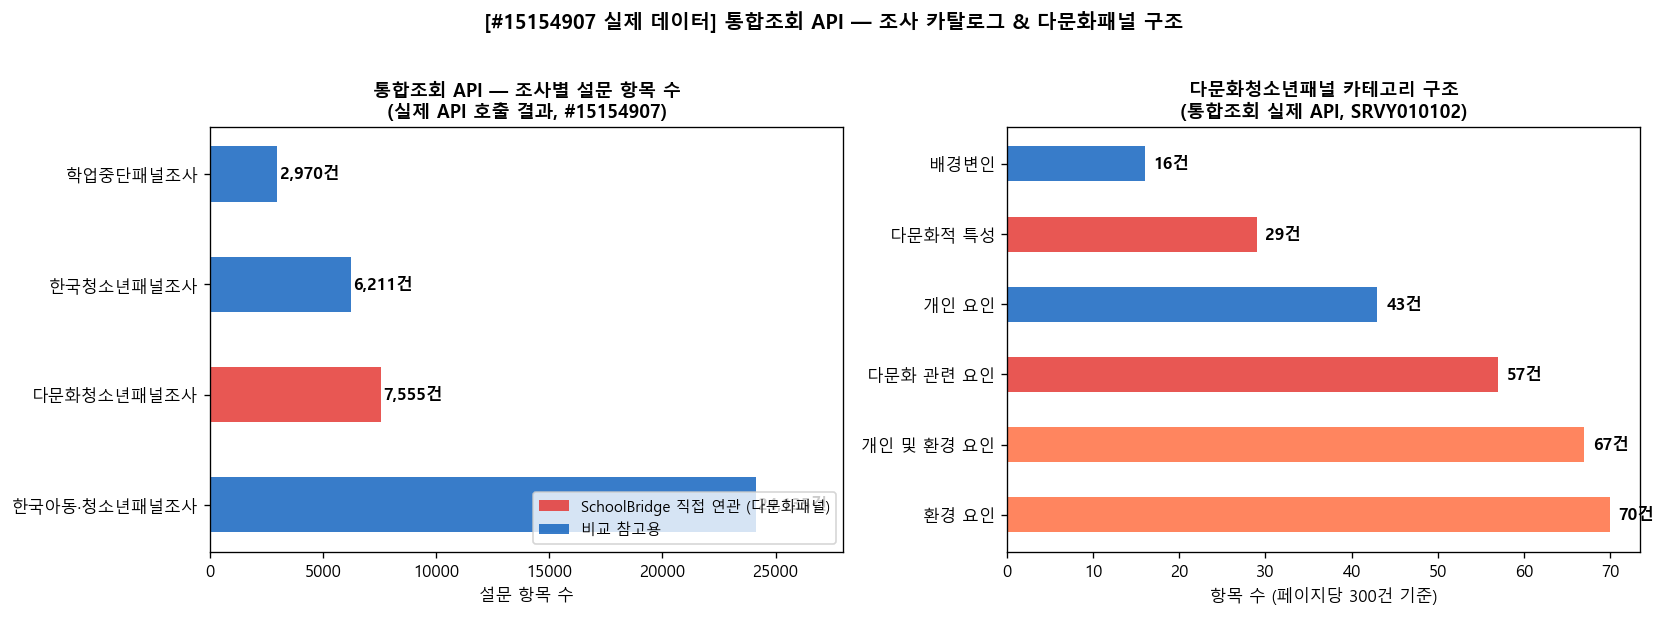

저장 완료: viz7_integrated_catalog.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── 왼쪽: 조사별 항목 수 bar ─────────────────────────────────
colors_cat = ['#E53935' if row['SB관련'] else '#1565C0'
              for _, row in catalog.iterrows()]
bars = axes[0].barh(catalog['조사명'], catalog['항목수'],
                    color=colors_cat, alpha=0.85, height=0.5)
for bar, val in zip(bars, catalog['항목수']):
    axes[0].text(val + 100, bar.get_y() + bar.get_height()/2,
                f'{val:,}건', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(0, 28000)
axes[0].set_xlabel('설문 항목 수')
axes[0].set_title('통합조회 API — 조사별 설문 항목 수\n(실제 API 호출 결과, #15154907)',
                 fontsize=11, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#E53935', alpha=0.85, label='SchoolBridge 직접 연관 (다문화패널)'),
    Patch(facecolor='#1565C0', alpha=0.85, label='비교 참고용'),
]
axes[0].legend(handles=legend_elements, fontsize=9, loc='lower right')

# ── 오른쪽: 다문화패널 카테고리 구조 ─────────────────────────
top_cats = maps_categories.nlargest(6, '항목수')
colors_mc = ['#E53935' if cat in ['다문화 관련 요인', '다문화적 특성'] else
             '#FF7043' if cat in ['환경 요인', '개인 및 환경 요인'] else '#1565C0'
             for cat in top_cats['카테고리']]
h_bars = axes[1].barh(top_cats['카테고리'], top_cats['항목수'],
                      color=colors_mc, alpha=0.85, height=0.5)
for bar, val in zip(h_bars, top_cats['항목수']):
    axes[1].text(val + 1, bar.get_y() + bar.get_height()/2,
                f'{val}건', va='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('항목 수 (페이지당 300건 기준)')
axes[1].set_title('다문화청소년패널 카테고리 구조\n(통합조회 실제 API, SRVY010102)',
                 fontsize=11, fontweight='bold')

plt.suptitle('[#15154907 실제 데이터] 통합조회 API — 조사 카탈로그 & 다문화패널 구조',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz7_integrated_catalog.png', bbox_inches='tight', dpi=150)
plt.show()
print('저장 완료: viz7_integrated_catalog.png')

## 3. 통합조회 API가 SchoolBridge에 유용한 이유

**실제 활용 시나리오:**
- `searchKeyword=학교생활`로 검색 → 4개 조사 중 어디에 학교생활 변수가 있는지 파악
- `opnDataCd=SRVY010102` + `searchKeyword=언어` → 다문화패널의 언어 관련 항목 목록 탐색
- `cbookAtchFileNm` / `rspvlAtchFileNm` 필드 → 코드북·응답 데이터 파일 다운로드 경로 제공

In [6]:
# 실제 검색 시연 — "학교" 키워드로 다문화패널 탐색
print('=== 실제 검색 시연: searchKeyword=학교 ===')
d_school = fetch_integrated({
    'opnDataCd': 'SRVY010102',
    'searchKeyword': '학교',
    'pageNo': 1, 'numOfRows': 10
})
print(f'다문화패널에서 "학교" 관련 항목: {d_school.get("totalCount", "?")}건')
print()
for item in d_school.get('items', [])[:5]:
    print(f'  [{item["srvyQitemId"]}] {item["cbookQitemCn"][:50]}')
    print(f'    카테고리: {item["otptCtgryNm"]}')
    print(f'    응답연도: {item["srvyYr"]}년, 응답주체: {item["rspnsMnbdNm"]}')
    print()

print('=== 코드북 다운로드 경로 예시 ===')
first_item = d_school['items'][0]
print(f'  코드북: https://data.nypi.re.kr{first_item.get("cbookAtchFileNm", "")}')
print(f'  응답값: https://data.nypi.re.kr{first_item.get("rspvlAtchFileNm", "")}')

=== 실제 검색 시연: searchKeyword=학교 ===
다문화패널에서 "학교" 관련 항목: 866건

  [diff_school_a01_w1] 학교생활의 어려운 점 세 가지1
    카테고리: 환경 요인-학교생활-학교생활의 어려운 점 세 가지
    응답연도: 2011년, 응답주체: 청소년

  [diff_school_a02_w1] 학교생활의 어려운 점 세 가지2
    카테고리: 환경 요인-학교생활-학교생활의 어려운 점 세 가지
    응답연도: 2011년, 응답주체: 청소년

  [diff_school_a03_w1] 학교생활의 어려운 점 세 가지3
    카테고리: 환경 요인-학교생활-학교생활의 어려운 점 세 가지
    응답연도: 2011년, 응답주체: 청소년

  [diff_study_01_w1] 학교공부의 어려운 점
    카테고리: 환경 요인-학교생활-학교공부의 어려운 점
    응답연도: 2011년, 응답주체: 청소년

  [help_community_01_w1] 학교 밖 도움을 주는 어른 유무
    카테고리: 환경 요인-지역사회 지지망-학교 밖에서 도움 받을 수 있는 사람
    응답연도: 2011년, 응답주체: 청소년

=== 코드북 다운로드 경로 예시 ===
  코드북: https://data.nypi.re.kr/api/files/download/codebook/다문화청소년패널 1기패널 청소년 1차년도_C.csv
  응답값: https://data.nypi.re.kr/api/files/download/response/다문화청소년패널 1기패널 청소년 1차년도.csv


## 4. 두 데이터셋의 역할 분담

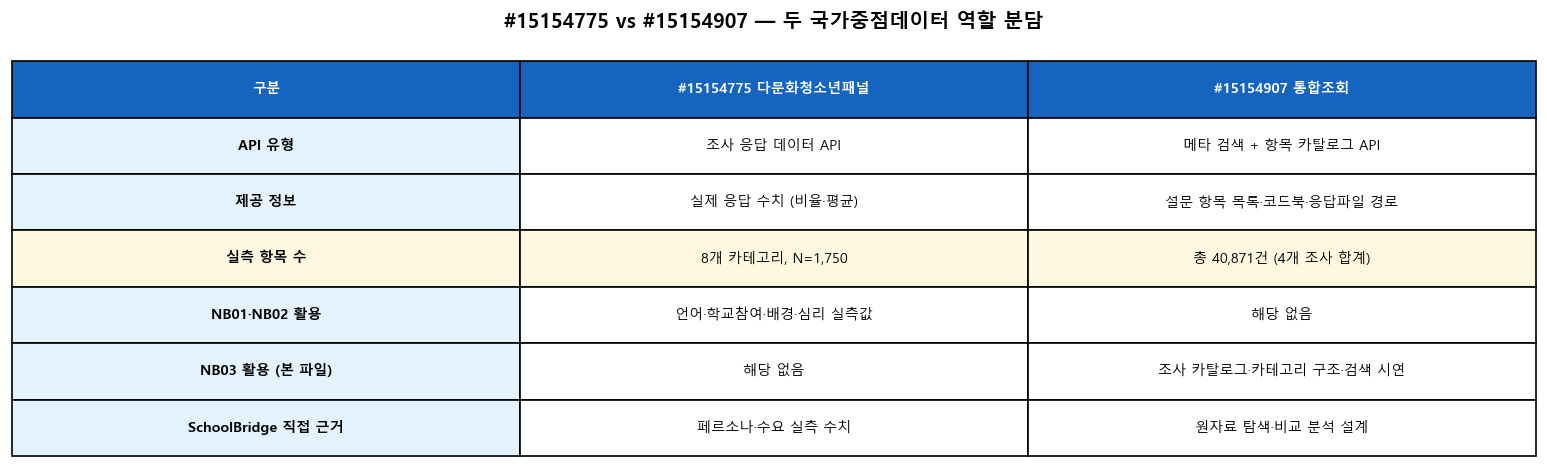

저장 완료: viz8_dataset_roles.png


In [7]:
# 역할 분담 표 시각화
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

table_data = [
    ['구분', '#15154775 다문화청소년패널', '#15154907 통합조회'],
    ['API 유형', '조사 응답 데이터 API', '메타 검색 + 항목 카탈로그 API'],
    ['제공 정보', '실제 응답 수치 (비율·평균)', '설문 항목 목록·코드북·응답파일 경로'],
    ['실측 항목 수', '8개 카테고리, N=1,750', '총 40,871건 (4개 조사 합계)'],
    ['NB01·NB02 활용', '언어·학교참여·배경·심리 실측값', '해당 없음'],
    ['NB03 활용 (본 파일)', '해당 없음', '조사 카탈로그·카테고리 구조·검색 시연'],
    ['SchoolBridge 직접 근거', '페르소나·수요 실측 수치', '원자료 탐색·비교 분석 설계'],
]

table = ax.table(cellText=table_data[1:], colLabels=table_data[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(8.5)

for j in range(3):
    table[0, j].set_facecolor('#1565C0')
    table[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_data)):
    table[i, 0].set_facecolor('#E3F2FD')
    table[i, 0].set_text_props(fontweight='bold')
for j in range(3):
    table[3, j].set_facecolor('#FFF8E1')

ax.set_title('#15154775 vs #15154907 — 두 국가중점데이터 역할 분담',
            fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz8_dataset_roles.png', bbox_inches='tight', dpi=150)
plt.show()
print('저장 완료: viz8_dataset_roles.png')

## 5. 종합 결론

### #15154907 통합조회 API 실측 확인 결과

| 조사명 | 코드 | 실제 항목 수 |
|---|---|---|
| 한국아동·청소년패널조사 | SRVY010101 | 24,135건 |
| 다문화청소년패널조사 | SRVY010102 | 7,555건 |
| 한국청소년패널조사 | SRVY010103 | 6,211건 |
| 학업중단패널조사 | SRVY010104 | 2,970건 |
| **합계** | — | **40,871건** |

### SchoolBridge 사업계획서 ⑭ 반영 방식
- **실측 근거 (이 노트북)**: API 직접 호출로 40,871개 설문 항목 메타데이터 확인
- **활용 방식**: searchKeyword 기반으로 관심 주제(학교·언어·진로) 탐색 → 원자료 신청 전 변수 확인
- **보완 역할**: NB01·NB02의 #15154775 실측 수치를 다른 조사와 비교 설계할 때 변수 목록 탐색에 활용

> API: https://data.nypi.re.kr/api/aoePlcyRscrWholInfo
> 데이터셋 번호: #15154907 (국가중점데이터, 사회복지 분야)